# Insurance Claim Fraud Detection

## 1. Import Libraries

In [140]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [141]:
df = pd.read_csv("insurance_claims_10k.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,278,47,581816,"Feb 25, 1990",oh,250/500,1000,1242.21,3000000,463-337,FEMALE,Associate,prof-specialty,chess,husband,0,0,2015-01-22,Single Vehicle Collision,Front Collision,Major Damage,Ambulance,WV,Northbend,3977 Apache Drive,NaN,1,YES,2,3,NO,68210,NaN,6200,55810,Toyota,Camry,1995,Y,NaN
1,464,57,978555,1992-07-30,IN,100/300,1000,1583.55,0,433924,FEMALE,NaN,sales,hiking,not-in-family,70300,-28500,2015-01-28,Multi-vehicle Collision,Rear Collision,Major Damage,Fire,VA,Hillsdale,5277 Apache St,16,2,YES,1,0,NO,66180,6020,12030,48130,Saab,93,2014,N,NaN
2,170,32,618236,20030401,OH,500/1000,2000,1221.12,0,441485,FEMALE,High School,other-service,dancing,not-in-family,0,0,10.01.2015,Single Vehicle Collision,Front Collision,Total Loss,Fire,VA,Riverwood,5760 4th Ave,10,1,YES,1,0,?,61990,6200,6200,49590,Dodge,RAM,1997,N,NaN
3,157,37,702580,1992-09-09,INDIANA,500/1000,NaN,912.65,0,620800,Female,Masters,exec-managerial,movies,own-child,0,0,2015-02-24,Multivehicle Collision,Side Collision,Minor Damage,Police,SC,Northbrook,8905 Solo Drive,17,3,NO,1,2,YES,69550,"$6,960",13910,48680,saab,95,2005,N,NaN
4,238,36,851599,2013-04-05,IN,500/1000,2000,1506.72,6000000,463938,FEMALE,High School,other-service,hiking,Not-In-Family,0,-49800,"February 15, 2015",Multi-vehicle Collision,Rear Collision,Major Damage,Ambulance,NY,Hillsdale,7114 Solo Drive,3,3,YES,2,1,YES,46360,9270,4640,32450.0,Dodge,RAM,2005,Y,NaN


## 3. Basic EDA

In [142]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Shape: (10000, 40)

Columns:
['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']

Data Types:


months_as_customer                 str
age                                str
policy_number                      str
policy_bind_date                   str
policy_state                       str
policy_csl                         str
policy_deductable                  str
policy_annual_premium              str
umbrella_limit                     str
insured_zip                        str
insured_sex                        str
insured_education_level            str
insured_occupation                 str
insured_hobbies                    str
insured_relationship               str
capital-gains                      str
capital-loss                       str
incident_date                      str
incident_type                      str
collision_type                     str
incident_severity                  str
authorities_contacted              str
incident_state                     str
incident_city                      str
incident_location                  str
incident_hour_of_the_day 


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           9871 non-null   str    
 1   age                          9773 non-null   str    
 2   policy_number                9987 non-null   str    
 3   policy_bind_date             9853 non-null   str    
 4   policy_state                 9947 non-null   str    
 5   policy_csl                   9941 non-null   str    
 6   policy_deductable            9937 non-null   str    
 7   policy_annual_premium        9756 non-null   str    
 8   umbrella_limit               9711 non-null   str    
 9   insured_zip                  9876 non-null   str    
 10  insured_sex                  9937 non-null   str    
 11  insured_education_level      9818 non-null   str    
 12  insured_occupation           9775 non-null   str    
 13  insure

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,9871,788,0,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,9773,153,39,418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_number,9987,9651,447740,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_bind_date,9853,7620,1990-01-01,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_state,9947,26,OH,3159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_csl,9941,36,250/500,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_deductable,9937,14,500,3326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_annual_premium,9756,8985,0.00,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
umbrella_limit,9711,42,0,7401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insured_zip,9876,8892,620962,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Values and Duplicates

In [143]:
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

print("Missing Values:")
display(missing_count[missing_count > 0])

print("Missing Percentage:")
display(missing_percentage[missing_percentage > 0])

print("Duplicate Rows:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Missing Values:


_c39                           10000
authorities_contacted           1135
capital-loss                     406
capital-gains                    366
umbrella_limit                   289
property_damage                  249
policy_annual_premium            244
injury_claim                     244
police_report_available          230
age                              227
property_claim                   226
insured_occupation               225
witnesses                        224
incident_location                191
vehicle_claim                    189
collision_type                   184
insured_education_level          182
bodily_injuries                  179
auto_model                       172
incident_hour_of_the_day         161
auto_year                        156
policy_bind_date                 147
insured_hobbies                  132
months_as_customer               129
incident_city                    124
insured_zip                      124
insured_relationship             121
i

Missing Percentage:


_c39                           100.00
authorities_contacted           11.35
capital-loss                     4.06
capital-gains                    3.66
umbrella_limit                   2.89
property_damage                  2.49
policy_annual_premium            2.44
injury_claim                     2.44
police_report_available          2.30
age                              2.27
property_claim                   2.26
insured_occupation               2.25
witnesses                        2.24
incident_location                1.91
vehicle_claim                    1.89
collision_type                   1.84
insured_education_level          1.82
bodily_injuries                  1.79
auto_model                       1.72
incident_hour_of_the_day         1.61
auto_year                        1.56
policy_bind_date                 1.47
insured_hobbies                  1.32
months_as_customer               1.29
incident_city                    1.24
insured_zip                      1.24
insured_rela

Duplicate Rows: 220
Duplicates removed. New shape: (9780, 40)


## 5. Initial Data Cleaning

In [144]:
if "_c39" in df.columns:
    df = df.drop(columns=["_c39"])

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()

invalid_values = ["?", "-", "--", "", "Unknown", "UNKNOWN", "unknown", "N/A", "NA"]
df = df.replace(invalid_values, np.nan)

print("Initial cleaning completed.")

Initial cleaning completed.


## 6. Target Variable Cleaning

In [145]:
TARGET = "fraud_reported"

print("Original target values:")
display(df[TARGET].value_counts(dropna=False))

target_mapping = {
    "Y": 1, "y": 1, "YES": 1, "Yes": 1, "yes": 1,
    "TRUE": 1, "True": 1, "true": 1, "1": 1, "Fraud": 1,
    "N": 0, "n": 0, "NO": 0, "No": 0, "no": 0,
    "FALSE": 0, "False": 0, "false": 0, "0": 0, "Non-Fraud": 0
}

df[TARGET] = df[TARGET].map(target_mapping)
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

print("Cleaned target:")
display(df[TARGET].value_counts())

display(df[TARGET].value_counts(normalize=True).mul(100))

Original target values:


fraud_reported
N            6673
Y            2227
No            104
Non-Fraud     100
no             92
false          92
0              88
FALSE          75
NaN            69
n              64
y              32
Yes            31
Fraud          30
1              29
yes            29
true           23
TRUE           22
Name: count, dtype: int64

Cleaned target:


fraud_reported
0    7288
1    2423
Name: count, dtype: int64

fraud_reported
0    75.048914
1    24.951086
Name: proportion, dtype: float64

## 7. Target Distribution

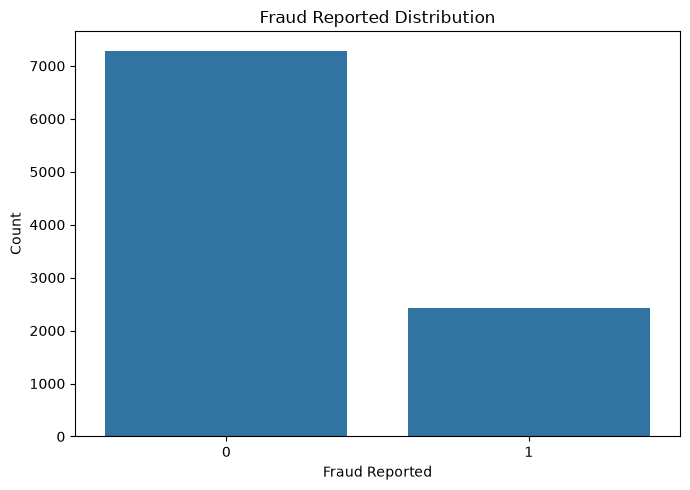

In [146]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET)
plt.title("Fraud Reported Distribution")
plt.xlabel("Fraud Reported")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 8. Numerical Data Cleaning

In [147]:
numeric_columns = [
    "months_as_customer", "age", "policy_deductable",
    "policy_annual_premium", "umbrella_limit", "insured_zip",
    "capital-gains", "capital-loss", "incident_hour_of_the_day",
    "number_of_vehicles_involved", "bodily_injuries", "witnesses",
    "total_claim_amount", "injury_claim", "property_claim",
    "vehicle_claim", "auto_year"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("$", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numerical conversion completed.")
display(df[numeric_columns].dtypes)

Numerical conversion completed.


months_as_customer             float64
age                            float64
policy_deductable              float64
policy_annual_premium          float64
umbrella_limit                 float64
insured_zip                    float64
capital-gains                  float64
capital-loss                   float64
incident_hour_of_the_day       float64
number_of_vehicles_involved    float64
bodily_injuries                float64
witnesses                      float64
total_claim_amount             float64
injury_claim                   float64
property_claim                 float64
vehicle_claim                  float64
auto_year                      float64
dtype: object

## 9. Categorical Data Cleaning

In [148]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.lower().str.strip()

if "policy_state" in df.columns:
    df["policy_state"] = df["policy_state"].replace({
        "illinois": "il", "indiana": "in", "ohio": "oh"
    })

if "insured_sex" in df.columns:
    df["insured_sex"] = df["insured_sex"].replace({
        "f": "female", "m": "male", "femal": "female", "mal": "male"
    })

if "incident_type" in df.columns:
    df["incident_type"] = df["incident_type"].replace({
        "single vehicle coll.": "single vehicle collision"
    })

if "incident_severity" in df.columns:
    df["incident_severity"] = df["incident_severity"].replace({
        "minor": "minor damage", "major": "major damage"
    })

for col in ["property_damage", "police_report_available"]:
    if col in df.columns:
        df[col] = df[col].replace({
            "true": "yes", "false": "no", "y": "yes", "n": "no",
            "1": "yes", "0": "no"
        })

if "number_of_vehicles_involved" in df.columns:
    df["number_of_vehicles_involved"] = df[
        "number_of_vehicles_involved"
    ].replace({"one": 1, "two": 2, "three": 3, "four": 4, "five": 5})
    df["number_of_vehicles_involved"] = pd.to_numeric(
        df["number_of_vehicles_involved"], errors="coerce"
    )

print("Categorical cleaning completed.")

Categorical cleaning completed.


## 10. Date Feature Engineering

In [149]:
df["policy_bind_date_parsed"] = pd.to_datetime(
    df["policy_bind_date"], errors="coerce", format="mixed"
)

df["incident_date_parsed"] = pd.to_datetime(
    df["incident_date"], errors="coerce", format="mixed"
)

invalid_year = ~df["policy_bind_date_parsed"].dt.year.between(1950, 2020)
df.loc[invalid_year, "policy_bind_date_parsed"] = pd.NaT

df["policy_bind_year"] = df["policy_bind_date_parsed"].dt.year
df["policy_bind_month"] = df["policy_bind_date_parsed"].dt.month
df["policy_bind_day"] = df["policy_bind_date_parsed"].dt.day

df["policy_age_years"] = (
    (df["incident_date_parsed"] - df["policy_bind_date_parsed"]).dt.days
    / 365.25
)

df.loc[
    (df["policy_age_years"] < 0) | (df["policy_age_years"] > 100),
    "policy_age_years"
] = np.nan

df["incident_month"] = df["incident_date_parsed"].dt.month
df["incident_dayofweek"] = df["incident_date_parsed"].dt.dayofweek

display(df[[
    "policy_bind_year", "policy_bind_month", "policy_bind_day",
    "policy_age_years", "incident_month", "incident_dayofweek"
]].head())

,policy_bind_year,policy_bind_month,policy_bind_day,policy_age_years,incident_month,incident_dayofweek
0,1990.0,2.0,25.0,24.906229,1.0,3.0
1,1992.0,7.0,30.0,22.496920,1.0,2.0
2,2003.0,4.0,1.0,12.501027,10.0,3.0
3,1992.0,9.0,9.0,22.458590,2.0,1.0
4,2013.0,4.0,5.0,1.864476,2.0,6.0


## 11. Feature Engineering — Claim Ratios

In [150]:
df["injury_claim_ratio"] = (
    df["injury_claim"] / df["total_claim_amount"]
)

df["property_claim_ratio"] = (
    df["property_claim"] / df["total_claim_amount"]
)

df["vehicle_claim_ratio"] = (
    df["vehicle_claim"] / df["total_claim_amount"]
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Feature engineering completed.")
display(df[[
    "injury_claim_ratio",
    "property_claim_ratio",
    "vehicle_claim_ratio"
]].head())

Feature engineering completed.


,injury_claim_ratio,property_claim_ratio,vehicle_claim_ratio
0,NaN,0.090896,0.818208
1,0.090964,0.181777,0.727259
2,0.100016,0.100016,0.799968
3,0.100072,0.200000,0.699928
4,0.199957,0.100086,0.699957


## 12. EDA — Distribution and Outlier Checking

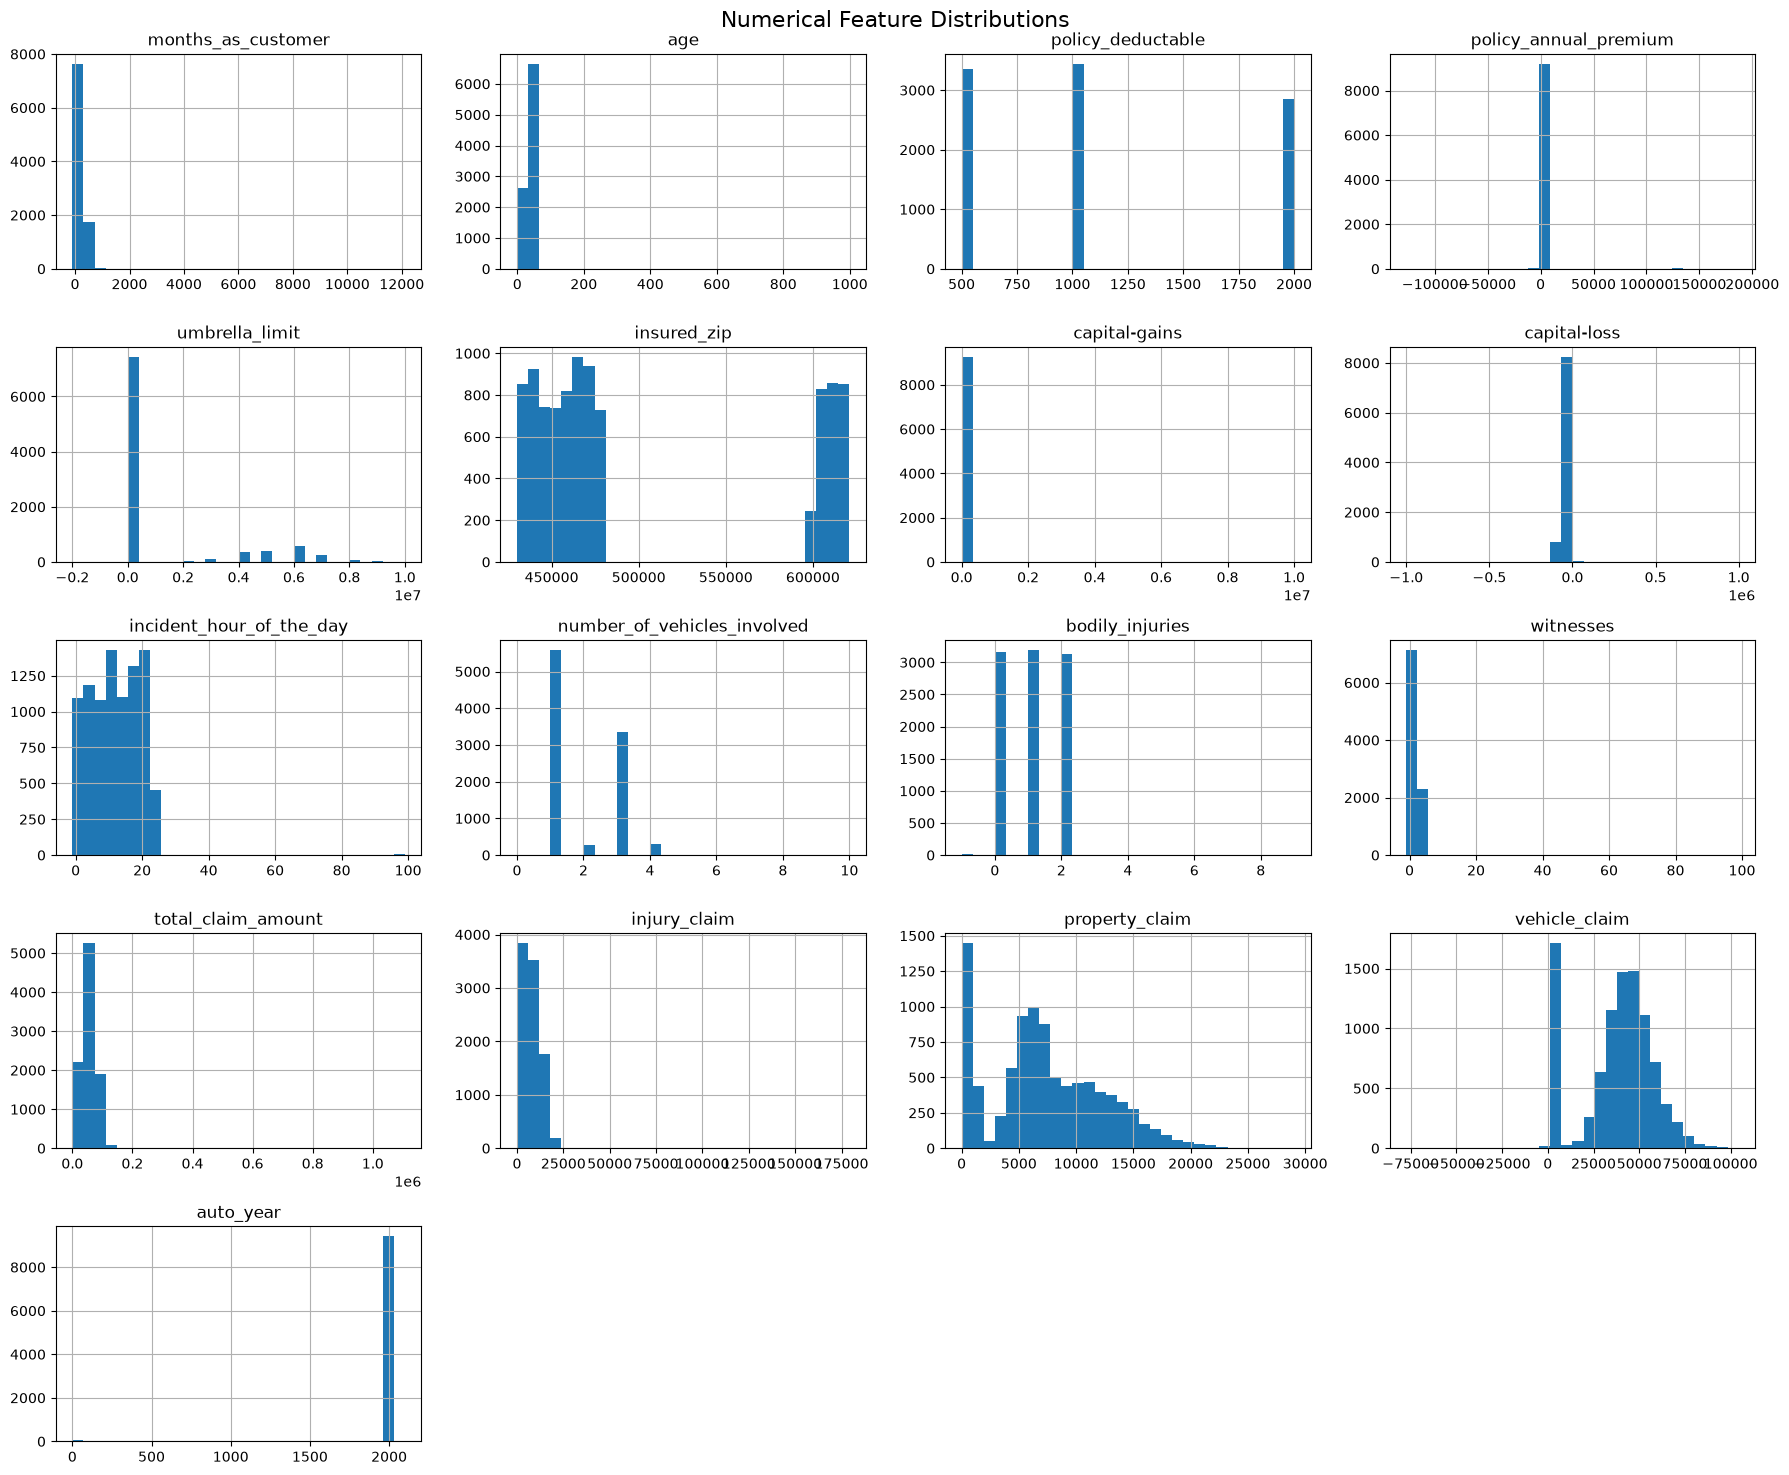

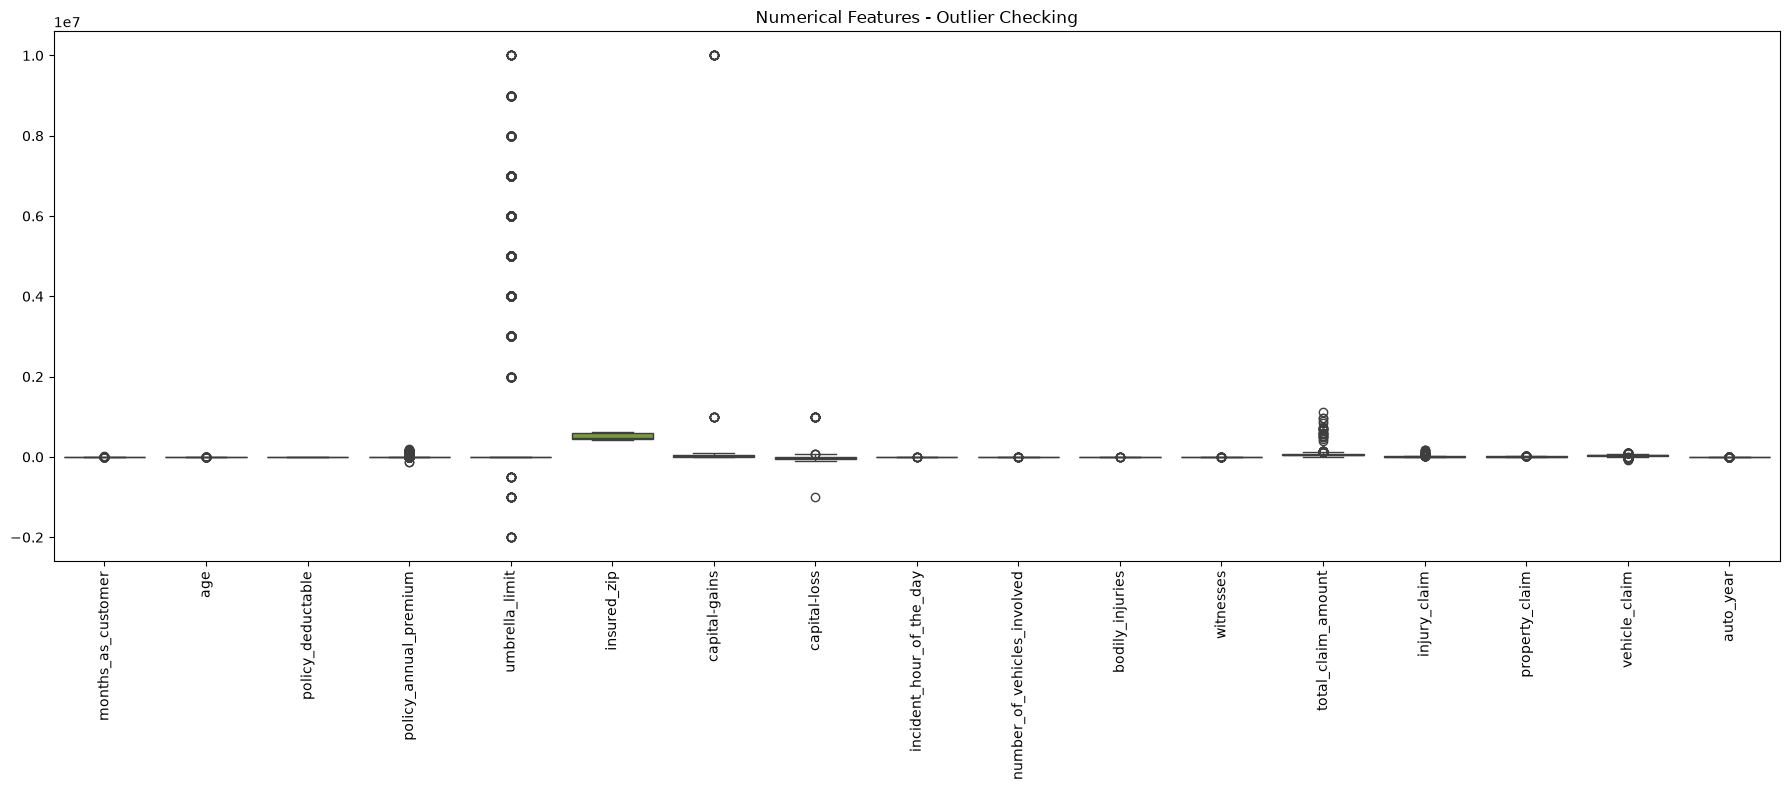

In [151]:
available_numeric_columns = [
    col for col in numeric_columns if col in df.columns
]

df[available_numeric_columns].hist(figsize=(18, 15), bins=30)
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 8))
sns.boxplot(data=df[available_numeric_columns])
plt.title("Numerical Features - Outlier Checking")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 13. Correlation Analysis

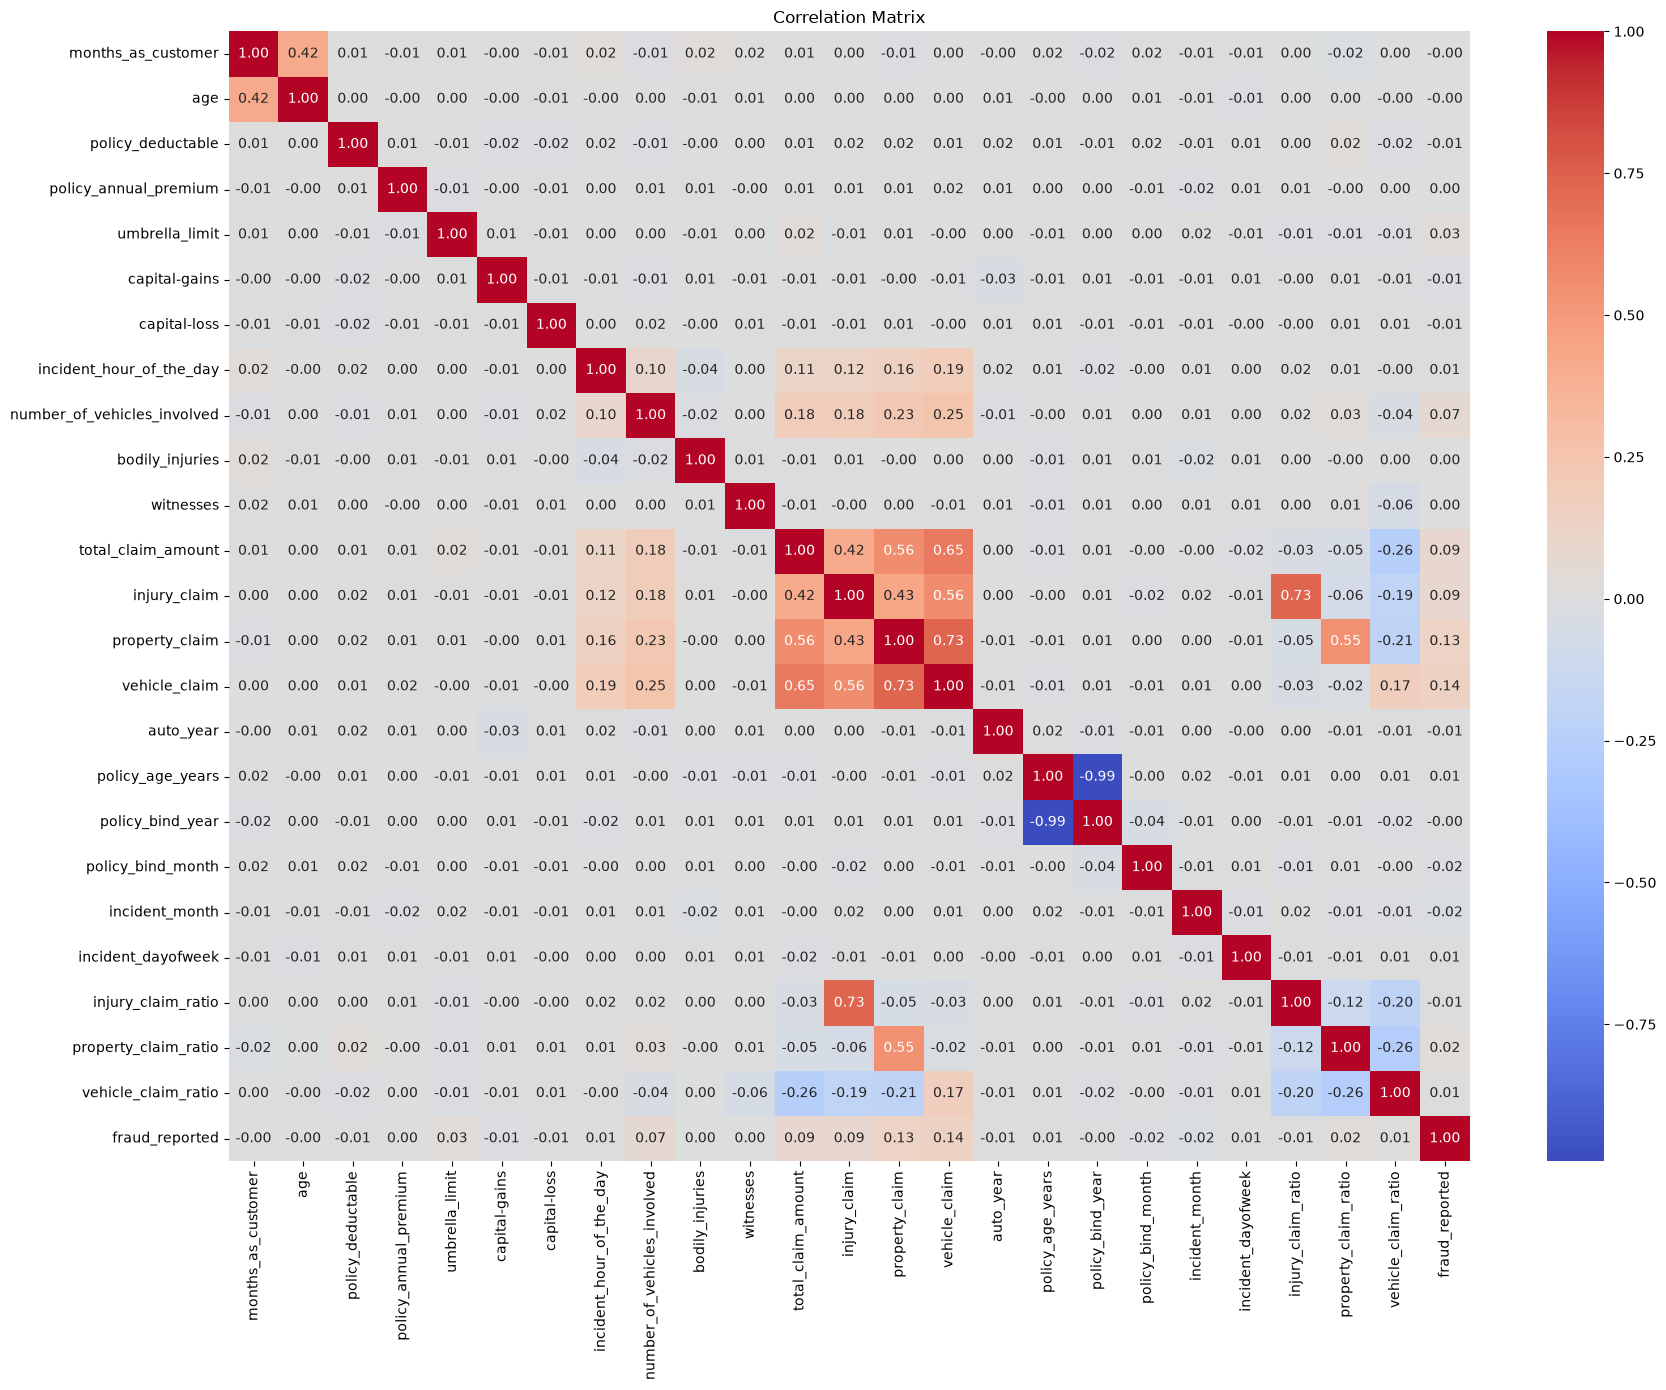

In [152]:
correlation_columns = [
    "months_as_customer", "age", "policy_deductable",
    "policy_annual_premium", "umbrella_limit", "capital-gains",
    "capital-loss", "incident_hour_of_the_day",
    "number_of_vehicles_involved", "bodily_injuries", "witnesses",
    "total_claim_amount", "injury_claim", "property_claim",
    "vehicle_claim", "auto_year", "policy_age_years",
    "policy_bind_year", "policy_bind_month", "incident_month",
    "incident_dayofweek", "injury_claim_ratio",
    "property_claim_ratio", "vehicle_claim_ratio", "fraud_reported"
]

correlation_columns = [c for c in correlation_columns if c in df.columns]
corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 14. Correlation With Target

In [153]:
target_correlation = (
    corr_matrix["fraud_reported"]
    .drop("fraud_reported")
    .sort_values(key=abs, ascending=False)
)

display(target_correlation)

vehicle_claim                  0.144410
property_claim                 0.130031
injury_claim                   0.085710
total_claim_amount             0.085077
number_of_vehicles_involved    0.068620
umbrella_limit                 0.028564
property_claim_ratio           0.023362
incident_month                -0.020528
policy_bind_month             -0.017649
vehicle_claim_ratio            0.012669
capital-gains                 -0.011471
capital-loss                  -0.011218
auto_year                     -0.009749
incident_hour_of_the_day       0.007467
policy_age_years               0.007280
policy_deductable             -0.006575
incident_dayofweek             0.006193
injury_claim_ratio            -0.005675
policy_bind_year              -0.003586
age                           -0.003463
witnesses                      0.003366
months_as_customer            -0.002293
bodily_injuries                0.001139
policy_annual_premium          0.000683
Name: fraud_reported, dtype: float64

## 15. Feature Selection — Remove ID / High-Cardinality Columns

In [154]:
columns_to_drop = [
    "fraud_reported",
    "policy_bind_date",
    "incident_date",
    "policy_bind_date_parsed",
    "incident_date_parsed",
    "policy_number",
    "insured_zip",
    "incident_location",
    "insured_hobbies"
]

columns_to_drop = [c for c in columns_to_drop if c in df.columns]

X = df.drop(columns=columns_to_drop)
y = df[TARGET].astype(int)

print("Feature count before encoding:", X.shape[1])
print(X.columns.tolist())

Feature count before encoding: 41
['months_as_customer', 'age', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'policy_bind_year', 'policy_bind_month', 'policy_bind_day', 'policy_age_years', 'incident_month', 'incident_dayofweek', 'injury_claim_ratio', 'property_claim_ratio', 'vehicle_claim_ratio']


## 16. Identify Numerical and Categorical Features

In [155]:
numerical_features = [
    c for c in X.columns
    if pd.api.types.is_numeric_dtype(X[c])
]

categorical_features = [
    c for c in X.columns
    if c not in numerical_features
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'policy_bind_year', 'policy_bind_month', 'policy_bind_day', 'policy_age_years', 'incident_month', 'incident_dayofweek', 'injury_claim_ratio', 'property_claim_ratio', 'vehicle_claim_ratio']

Categorical Features:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


In [156]:
# ============================================================
# SELECT FEATURES FOR MODEL
# ============================================================

# ui_features = [
#     "age",
#     "months_as_customer",
#     "insured_sex",
#     "policy_state",
#     "policy_csl",
#     "policy_deductable",
#     "policy_annual_premium",
#     "policy_age_years",
#     "incident_type",
#     "incident_severity",
#     "number_of_vehicles_involved",
#     "bodily_injuries",
#     "witnesses",
#     "total_claim_amount",
#     "injury_claim",
#     "property_claim",
#     "vehicle_claim"
# ]

# X = df[ui_features].copy()
# y = df["fraud_reported"].copy()

# print("Number of independent features:", X.shape[1])
# print("Features:", X.columns.tolist())

## 17. Train-Test Split

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).mul(100))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).mul(100))

Training Shape: (7768, 41)
Testing Shape : (1943, 41)

Training target distribution:


fraud_reported
0    75.051493
1    24.948507
Name: proportion, dtype: float64


Testing target distribution:


fraud_reported
0    75.0386
1    24.9614
Name: proportion, dtype: float64

## 18. Data Preprocessing — Imputation, Encoding and Scaling

In [122]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 19. Feature Selection — Mutual Information

In [123]:
feature_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=100
)

print("Top 100 transformed features will be selected.")

Top 100 transformed features will be selected.


In [124]:
print("X_train shape:", X_train.shape)

X_train shape: (7768, 41)


## 20. Logistic Regression Model

In [125]:
logistic_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", feature_selector),
    ("logistic_regression", logistic_model)
])

print("Complete Logistic Regression pipeline created.")

Complete Logistic Regression pipeline created.


## 21. Model Training

In [126]:
model_pipeline.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


## 22. Model Prediction

In [127]:
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

print("Predictions generated.")

Predictions generated.


## 23. Accuracy

In [128]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 0.8018
Testing Accuracy : 0.7921


## 24. Precision, Recall and F1 Score

In [129]:
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Precision: 0.5714
Recall   : 0.6680
F1 Score : 0.6160


## 25. Classification Report

In [130]:
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      1458
           1       0.57      0.67      0.62       485

    accuracy                           0.79      1943
   macro avg       0.73      0.75      0.74      1943
weighted avg       0.81      0.79      0.80      1943



## 26.1. Confusion Matrix

[[4916  914]
 [ 626 1312]]


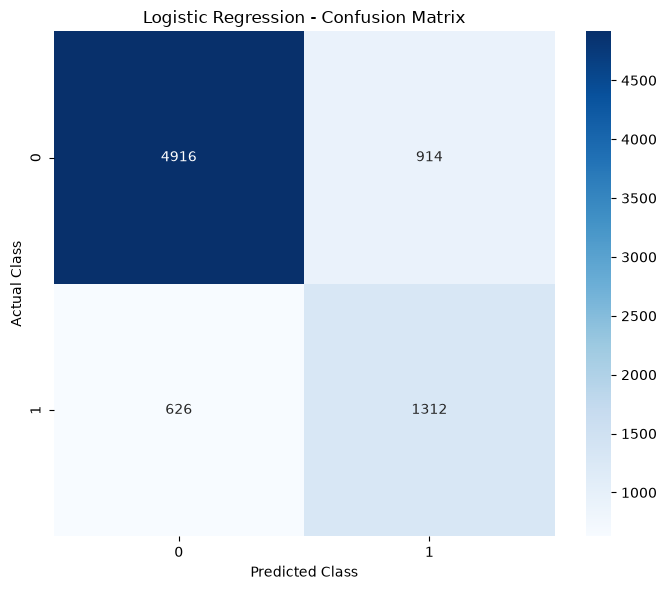

In [131]:
cmtrain = confusion_matrix(y_train, y_train_pred)

print(cmtrain)

plt.figure(figsize=(7, 6))
sns.heatmap(cmtrain, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 26.2. Confusion Matrix

[[1215  243]
 [ 161  324]]


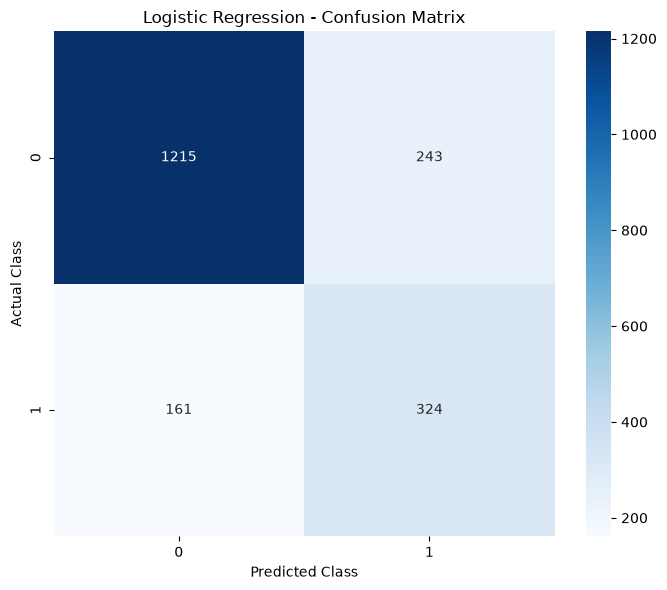

In [132]:
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion Matrix Meaning

- **TN:** Correctly predicted Non-Fraud
- **FP:** Non-Fraud predicted as Fraud
- **FN:** Fraud predicted as Non-Fraud
- **TP:** Correctly predicted Fraud

For fraud detection, **Recall is important** because a False Negative means a fraudulent claim was missed.

## 27. ROC-AUC Score

In [133]:
y_probability = model_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7792


## 28. ROC Curve

[0.00000000e+00 0.00000000e+00 6.85871056e-04 6.85871056e-04
 1.37174211e-03 1.37174211e-03 2.74348422e-03 2.74348422e-03
 3.42935528e-03 3.42935528e-03 4.11522634e-03 4.11522634e-03
 4.80109739e-03 4.80109739e-03 5.48696845e-03 5.48696845e-03
 6.85871056e-03 6.85871056e-03 7.54458162e-03 7.54458162e-03
 8.91632373e-03 8.91632373e-03 1.09739369e-02 1.09739369e-02
 1.16598080e-02 1.16598080e-02 1.30315501e-02 1.30315501e-02
 1.37174211e-02 1.37174211e-02 1.44032922e-02 1.44032922e-02
 1.71467764e-02 1.71467764e-02 1.92043896e-02 1.92043896e-02
 2.05761317e-02 2.05761317e-02 2.19478738e-02 2.19478738e-02
 2.33196159e-02 2.33196159e-02 2.67489712e-02 2.67489712e-02
 2.74348422e-02 2.74348422e-02 2.81207133e-02 2.81207133e-02
 2.94924554e-02 2.94924554e-02 3.01783265e-02 3.01783265e-02
 3.08641975e-02 3.08641975e-02 3.15500686e-02 3.15500686e-02
 3.22359396e-02 3.22359396e-02 3.29218107e-02 3.29218107e-02
 3.36076818e-02 3.36076818e-02 3.42935528e-02 3.42935528e-02
 3.56652949e-02 3.566529

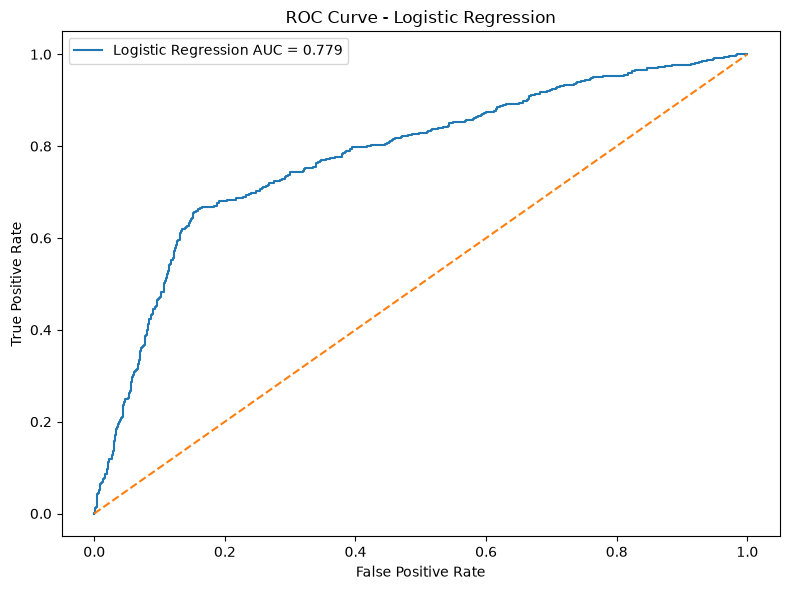

In [159]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    label=f"Logistic Regression AUC = {roc_auc:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

## 29. Final Model Performance Summary

In [135]:
results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(results)

,Metric,Score
0,Training Accuracy,0.801751
1,Testing Accuracy,0.792074
2,Precision,0.571429
3,Recall,0.668041
4,F1 Score,0.615970
5,ROC-AUC,0.779232


## 30. Save the Trained Model

In [136]:
MODEL_FILE = "logistic_regression_insurance_model.pkl"

joblib.dump(model_pipeline, MODEL_FILE)

print(f"Model saved successfully: {MODEL_FILE}")

Model saved successfully: logistic_regression_insurance_model.pkl


## 31. Load Saved Model

In [137]:
loaded_model = joblib.load(MODEL_FILE)
print("Saved model loaded successfully.")

Saved model loaded successfully.


## 32. Sample Prediction

In [ ]:
sample_data = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(sample_data)
sample_probability = loaded_model.predict_proba(sample_data)[0][1]

print("Actual Class:", y_test.iloc[0])

if sample_prediction[0] == 1:
    print("Prediction: FRAUD")
else:
    print("Prediction: NON-FRAUD")

print(f"Fraud Probability: {sample_probability:.4f}")